# Airbnb Hypothesis Testing

가설검정과 시각화를 다시 재현하기 위한 노트북이다.

- 자치구별 평균 가격 차이
- Manhattan vs Non-Manhattan
- 방 유형별 가격 차이
- 지하철 접근성에 따른 가격 차이
- 범죄 수준에 따른 가격 차이
- 관광지 수준에 따른 가격 차이

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import f_oneway, ttest_ind

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [2]:
input_path = Path('../data/processed/airbnb_preprocessed_df.csv')
airbnb_df = pd.read_csv(input_path)

print(airbnb_df.shape)
airbnb_df[['neighbourhood_group', 'room_type', 'log_price']].head()

(47928, 47)


,neighbourhood_group,room_type,log_price
0,Brooklyn,Private room,5.010635
1,Manhattan,Entire home/apt,5.420535
2,Manhattan,Private room,5.017280
3,Brooklyn,Entire home/apt,4.499810
4,Manhattan,Entire home/apt,4.394449


## 4.1 자치구별 평균 가격

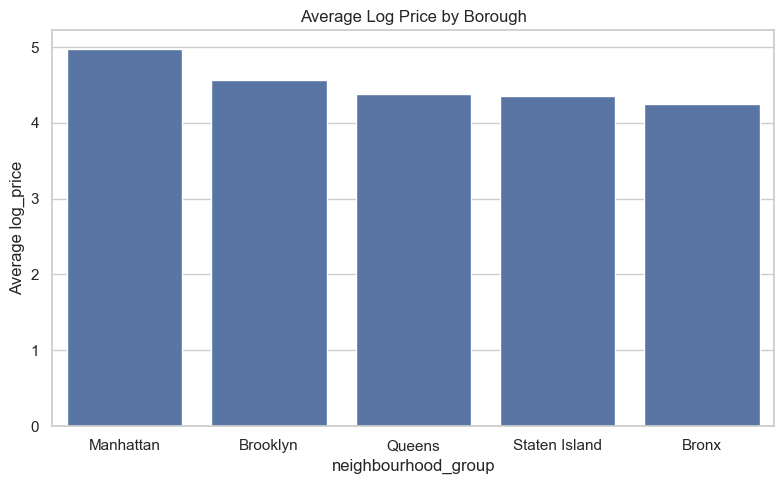

,neighbourhood_group,log_price
2,Manhattan,4.973141
1,Brooklyn,4.565541
3,Queens,4.378505
4,Staten Island,4.354737
0,Bronx,4.253539


In [3]:
borough_order = ['Manhattan', 'Brooklyn', 'Queens', 'Staten Island', 'Bronx']

borough_mean = (
    airbnb_df.groupby('neighbourhood_group', as_index=False)['log_price']
    .mean()
)

borough_mean['neighbourhood_group'] = pd.Categorical(
    borough_mean['neighbourhood_group'],
    categories=borough_order,
    ordered=True
)
borough_mean = borough_mean.sort_values('neighbourhood_group')

plt.figure(figsize=(8, 5))
sns.barplot(data=borough_mean, x='neighbourhood_group', y='log_price')
plt.title('Average Log Price by Borough')
plt.xlabel('neighbourhood_group')
plt.ylabel('Average log_price')
plt.tight_layout()
plt.show()

borough_mean

In [4]:
groups = [
    group['log_price'].values
    for _, group in airbnb_df.groupby('neighbourhood_group')
]

f_stat, p_value = f_oneway(*groups)

print('H0: 자치구별 평균 가격은 차이가 없다.')
print('H1: 자치구별 평균 가격은 차이가 있다.')
print('F-stat:', f_stat)
print('p-value:', p_value)

H0: 자치구별 평균 가격은 차이가 없다.
H1: 자치구별 평균 가격은 차이가 있다.
F-stat: 1906.5972873617839
p-value: 0.0


### 4.1.3 is_manhattan vs non_manhattan 추가 검정

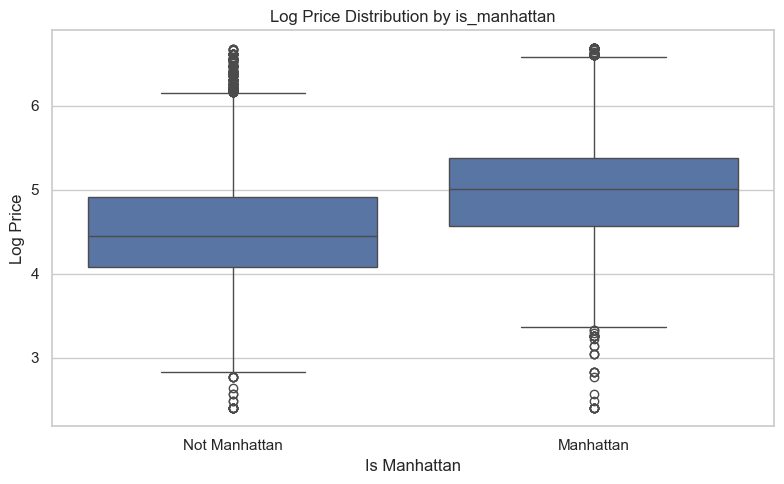

In [5]:
airbnb_df['is_manhattan_group'] = airbnb_df['neighbourhood_group'].eq('Manhattan').map({True: 'Manhattan', False: 'Not Manhattan'})

plt.figure(figsize=(8, 5))
sns.boxplot(data=airbnb_df, x='is_manhattan_group', y='log_price', order=['Not Manhattan', 'Manhattan'])
plt.title('Log Price Distribution by is_manhattan')
plt.xlabel('Is Manhattan')
plt.ylabel('Log Price')
plt.tight_layout()
plt.show()

In [6]:
manhattan = airbnb_df.loc[airbnb_df['neighbourhood_group'] == 'Manhattan', 'log_price']
non_manhattan = airbnb_df.loc[airbnb_df['neighbourhood_group'] != 'Manhattan', 'log_price']

t_stat, p_value = ttest_ind(manhattan, non_manhattan, equal_var=False)

print('H0: manhattan 숙소와 non manhattan 숙소의 평균 log_price는 차이가 없다.')
print('H1: manhattan 숙소와 non manhattan 숙소의 평균 log_price는 차이가 있다.')
print('t-statistic:', t_stat)
print('p-value:', p_value)

H0: manhattan 숙소와 non manhattan 숙소의 평균 log_price는 차이가 없다.
H1: manhattan 숙소와 non manhattan 숙소의 평균 log_price는 차이가 있다.
t-statistic: 82.83616170926389
p-value: 0.0


## 4.2 방 유형에 따른 가격 차이

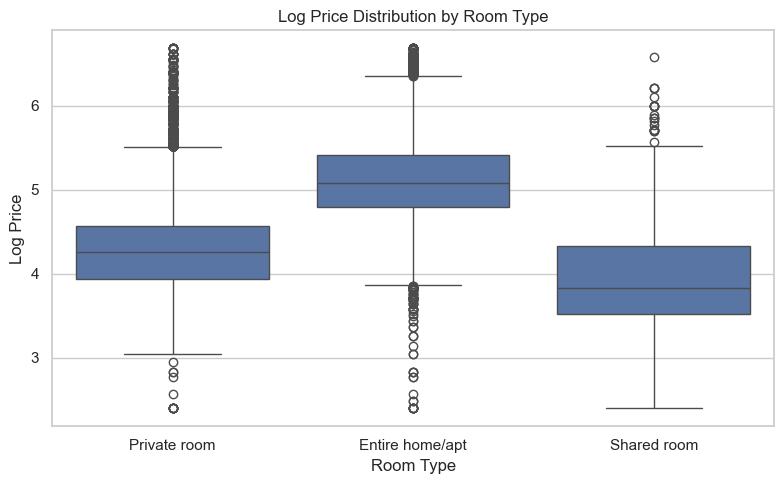

In [7]:
room_order = ['Private room', 'Entire home/apt', 'Shared room']

plt.figure(figsize=(8, 5))
sns.boxplot(data=airbnb_df, x='room_type', y='log_price', order=room_order)
plt.title('Log Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Log Price')
plt.tight_layout()
plt.show()

In [8]:
groups = [
    group['log_price'].values
    for _, group in airbnb_df.groupby('room_type')
]

f_stat, p_value = f_oneway(*groups)

print('H0: 방 유형별 평균 가격은 차이가 없다.')
print('H1: 방 유형별 평균 가격은 차이가 있다.')
print('F-stat:', f_stat)
print('p-value:', p_value)

H0: 방 유형별 평균 가격은 차이가 없다.
H1: 방 유형별 평균 가격은 차이가 있다.
F-stat: 17406.40434584354
p-value: 0.0


## 4.3 지하철 접근성이 숙소 가격에 미치는 영향

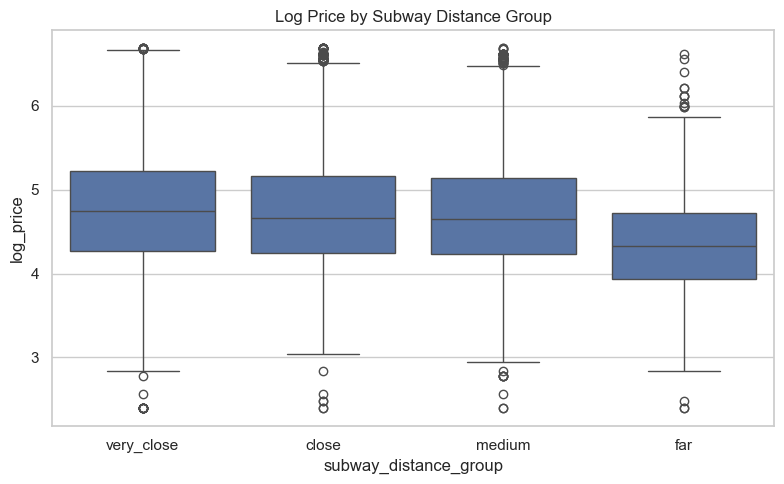

In [9]:
subway_df = airbnb_df.copy()
subway_df['subway_distance_group'] = pd.cut(
    subway_df['distance_to_nearest_station'],
    bins=[0, 0.3, 0.5, 1.0, 2.0],
    labels=['very_close', 'close', 'medium', 'far'],
    include_lowest=True,
    right=True
)
subway_df = subway_df.dropna(subset=['subway_distance_group'])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=subway_df,
    x='subway_distance_group',
    y='log_price',
    order=['very_close', 'close', 'medium', 'far']
)
plt.title('Log Price by Subway Distance Group')
plt.xlabel('subway_distance_group')
plt.ylabel('log_price')
plt.tight_layout()
plt.show()

In [10]:
groups = [
    group['log_price'].values
    for _, group in subway_df.groupby('subway_distance_group', observed=False)
]

f_stat, p_value = f_oneway(*groups)

print('H0: 지하철 접근성에 따라 숙소 가격 차이는 없다.')
print('H1: 지하철 접근성에 따라 숙소 가격 차이가 있다.')
print('F-stat:', f_stat)
print('p-value:', p_value)

H0: 지하철 접근성에 따라 숙소 가격 차이는 없다.
H1: 지하철 접근성에 따라 숙소 가격 차이가 있다.
F-stat: 146.78036710085013
p-value: 1.1267424956986088e-94


## 4.4 범죄 수준이 숙소 가격에 미치는 영향

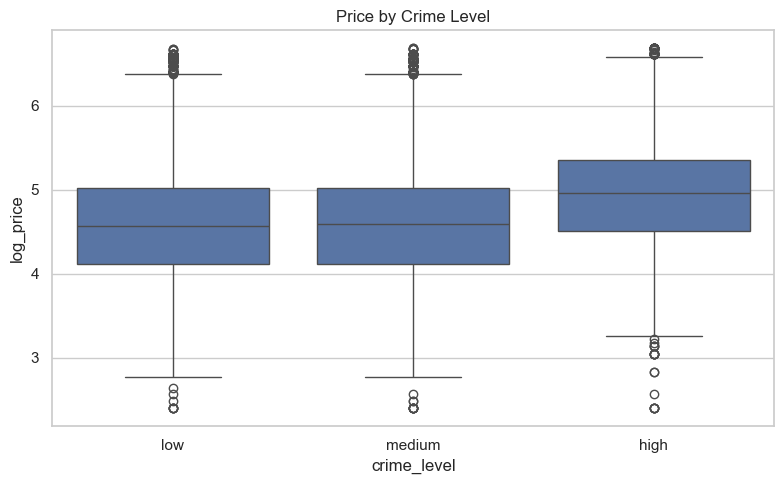

In [11]:
crime_df = airbnb_df.copy()
crime_df['crime_level'] = pd.qcut(
    crime_df['crime_count_0.5km'],
    q=3,
    labels=['low', 'medium', 'high'],
    duplicates='drop'
)

plt.figure(figsize=(8, 5))
sns.boxplot(data=crime_df, x='crime_level', y='log_price', order=['low', 'medium', 'high'])
plt.title('Price by Crime Level')
plt.xlabel('crime_level')
plt.ylabel('log_price')
plt.tight_layout()
plt.show()

In [12]:
groups = [
    group['log_price'].values
    for _, group in crime_df.groupby('crime_level', observed=False)
]

f_stat, p_value = f_oneway(*groups)

print('H0: 범죄 수준에 따라 숙소 가격 차이는 없다.')
print('H1: 범죄 수준에 따라 숙소 가격 차이가 있다.')
print('F-stat:', f_stat)
print('p-value:', p_value)

H0: 범죄 수준에 따라 숙소 가격 차이는 없다.
H1: 범죄 수준에 따라 숙소 가격 차이가 있다.
F-stat: 1594.8243689315573
p-value: 0.0


## 4.5 주변 관광지가 숙소 가격에 미치는 영향

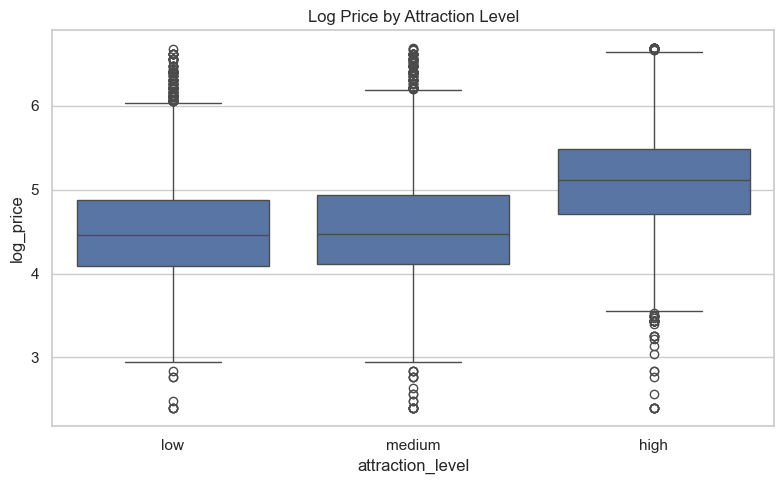

In [14]:
attraction_df = airbnb_df.copy()

attraction_df['attraction_level'] = pd.qcut(
    attraction_df['attraction_count_2km'].rank(method='first'),
    q=3,
    labels=['low', 'medium', 'high']
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=attraction_df,
    x='attraction_level',
    y='log_price',
    order=['low', 'medium', 'high']
)
plt.title('Log Price by Attraction Level')
plt.xlabel('attraction_level')
plt.ylabel('log_price')
plt.tight_layout()
plt.show()


In [15]:
groups = [
    group['log_price'].values
    for _, group in attraction_df.groupby('attraction_level', observed=False)
]

f_stat, p_value = f_oneway(*groups)

print('H0: 관광지 수준에 따라 숙소 가격 차이는 없다.')
print('H1: 관광지 수준에 따라 숙소 가격 차이가 있다.')
print('F-stat:', f_stat)
print('p-value:', p_value)


H0: 관광지 수준에 따라 숙소 가격 차이는 없다.
H1: 관광지 수준에 따라 숙소 가격 차이가 있다.
F-stat: 5815.057414761852
p-value: 0.0
